In [3]:
import pandas as pd
import numpy as np
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle, re, collections, shutil, vcf
from functools import reduce
from itertools import product

import scipy.stats as st
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
import statsmodels.stats.api as stm
import statsmodels.api as sm
import sklearn
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.utils.class_weight import compute_class_weight

# for survival analysis
import lifelines
from epi_utils import *
from datetime import datetime

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETA",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMI",
                  "Pretomanid": "PTM",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LEV",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {val: key for key, val in drug_abbr_dict.items()}

# 7H10 critical concentrations dictionary
cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100}

cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/critical_concentrations_WHO_catalog.csv")

drugs_lst = ['RIF', 'INH', 'EMB', 'PZA']

who_variants = pd.read_csv("../../data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
silent_lst = ['synonymous_variant', 'initiator_codon_variant', 'stop_retained_variant']

isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/isolate_variants_WHO_catalog.csv")

# MIC encoding from the TRUST codebook
MIC_encoding_dicts = {'RIF': {1: '0,0.03', 2: '0.03,0.06', 3: '0.06,0.125', 4: '0.125,0.25', 5: '0.25,0.5', 6: '0.5,1', 7: '1,inf'},
                      'INH': {1: '0,0.025', 2: '0.025,0.05', 3: '0.05,0.1', 4: '0.1,0.2', 5: '0.2,inf'},
                      'EMB': {1: '0,0.6', 2: '0.6,1.25', 3: '1.25,2.5', 4: '2.5,5', 5: '5,inf'},
                      'PZA': {1: '0,25', 2: '25,50', 3: '50,75', 4: '75,100', 5: '100,inf'}
                     }

final_keep_pids = pd.read_csv("final_keep_pids.txt", sep='\t', header=None)[0].values
print(f"Kept {len(final_keep_pids)} pids for survival models")

Kept 362 pids for survival models


# Read in all patient data -- RedCap, predicted MICs, and measured MICs transformed to µg/mL in MGIT

In [11]:
# this is all 452 patients, no exclusions based on the availability of WGS or validity for the TCC analysis
df_full = pd.read_csv("data/20240826_metadata_MIC_method_updates.csv")

# this is all WGS samples that we have matched with patients, not just WGS at baseline
df_full_WGS = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/clinical_data/combined_patient_WGS_data.csv")

In [12]:
df_TTP_smear, df_TCC, df_combined_culture_results = get_combined_culture_results(df_full)
print(f"{df_TCC.pid.nunique()} pids for the TCC analysis")
print(f"{df_TTP_smear.dropna(subset='culture_sample_num').query('culture_sample_num <= 5').pid.nunique()} pids with baseline TTPs within the first 5 weeks")

391 pids for the TCC analysis
409 pids with baseline TTPs within the first 5 weeks


In [13]:
df_trust_patients, TRUST_phenos, df_pred_combined = read_combine_all_TRUST_data("./processed_data/combined_patient_WGS_data.csv", 
                                                                                {'RIF': 'lineage_amino_acid', 
                                                                                 'INH': 'lineage_amino_acid', 
                                                                                 'EMB': 'lineage_amino_acid', 
                                                                                 'PZA': 'amino_acid'}, # dictionary for which model to get predictions for
                                                                                CNN_results_dir="/n/data1/hms/dbmi/farhat/Sanjana/CNN_results", 
                                                                                baseline_only=True
                                                                               )

# also run on this so that the variables are in better encodings
df_trust_patients = process_patient_metadata_better_encodings(df_trust_patients, TRUST_phenos, df_TTP_smear=df_TTP_smear, include_TTP=True)

print(f"{df_trust_patients.merge(df_TCC, on='pid').pid.nunique()}/{df_trust_patients.pid.nunique()} patients with valid TCC, WGS, and MICs")

418 patients with any WGS samples
418 patients with uncontaminated WGS samples
408 patients with uncontaminated WGS samples taken in the first 2 weeks

2 patients: ['T0137' 'T0402'] have multiple sequences at the same timepoint
Removing 1 patients: ['T0402'] because there are multiple WGS samples at the same timepoint with different lineages
409 patients have MICs for RIF
409 patients have MICs for INH
409 patients have MICs for EMB
288 patients have MICs for PZA
405 patients have measured MICs in the first 2 weeks

Found predicted RIF MICs for 407 pids
Found predicted INH MICs for 407 pids
Found predicted EMB MICs for 407 pids
Found predicted PZA MICs for 407 pids
407 patients have predicted MICs
379/407 patients with valid TCC, WGS, and MICs


In [14]:
df_full = add_household_numbers(df_full)
df_full.dropna(subset='bl_housecode').groupby("bl_housecode")['pid'].nunique().unique()

82 patients share a household with another patient, accounting for 32 households
402 unique households across 452 patients


array([4, 2, 3, 6, 5])

In [15]:
# just to get the counts
df_trust_patients = add_household_numbers(df_trust_patients)
df_trust_patients.dropna(subset='bl_housecode').groupby("bl_housecode")['pid'].nunique().unique()

68 patients share a household with another patient, accounting for 31 households
370 unique households across 407 patients


array([4, 2, 3, 1, 6])

In [16]:
pli_predictions = get_percent_long_involvement_predictions()

453 total pids


In [17]:
df_trust_patients.drop_duplicates(subset='pid').query("pid in @final_keep_pids")['diabetes'].mean()

0.052486187845303865

In [18]:
len(df_trust_patients.drop_duplicates(subset='pid').query("pid in @final_keep_pids").query("bl_bmi < 18")) / len(df_trust_patients.drop_duplicates(subset='pid').query("pid in @final_keep_pids"))

0.5524861878453039

In [19]:
len(df_trust_patients.drop_duplicates(subset='pid').query("pid in @final_keep_pids").query("bl_bmi > 25")) / len(df_trust_patients.drop_duplicates(subset='pid'))

0.03931203931203931

In [20]:
df_trust_patients.query("pid in @final_keep_pids").pid.nunique()

362

In [13]:
def process_dates_table(df_full, dates_fName):

    df_dates = pd.read_csv(dates_fName)
    
    # skip first column, which is pid, and convert the rest to datetime format
    for col in df_dates.columns[1:]:
        df_dates[col] = pd.to_datetime(df_dates[col], format='%m/%d/%Y')
    
        if " " in col:
            df_dates.rename(columns={col: col.replace(' ', '_')}, inplace=True)

    # combine with the treatment outcomes for easy look up
    df_dates = df_dates.merge(df_full[['pid', 'to_studyto_treatment_outcome', 'esp_reason_end_of_study_parti', 'esp_reasonoth_end_of_study_parti', 'esp_cod_end_of_study_parti']], on='pid')

    return df_dates

In [14]:
df_dates = process_dates_table(df_full, "raw_data/TRUST_Dates_10.29.24.csv")

In [15]:
# df_WHO_variants = []
# failed_samples = []

# for sampleID in df_full_WGS.SampleID.values:

#     WHO_variants_fName = f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_processed/{sampleID}/WHO_resistance/{sampleID}_variants_annot.tsv"

#     if os.path.isfile(WHO_variants_fName):
#         df = pd.read_csv(WHO_variants_fName, sep='\t')
#         df['SampleID'] = sampleID
#         df_WHO_variants.append(df.query("confidence=='1) Assoc w R'"))
#     else:
#         # some don't have FASTQs. If they do, they must be highly contaminated
#         if os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_processed/{sampleID}"):
#             failed_samples.append(sampleID)

# df_WHO_variants = pd.concat(df_WHO_variants)

# Make a heatmap of the cultures

In [11]:
cultures_for_heatmap = df_combined_culture_results.query("sample_num <= 12 & pid in @final_keep_pids").pivot(index='pid', columns='sample_num', values='result')

# same thing done before computing TCC and running imputation
cultures_for_heatmap = cultures_for_heatmap.replace('tb_positive_contaminated', 'tb_positive').replace('tb_negative_contaminated', np.nan).replace('tb_positive', 1).replace('tb_negative', 0)
cultures_for_heatmap.shape

(362, 12)

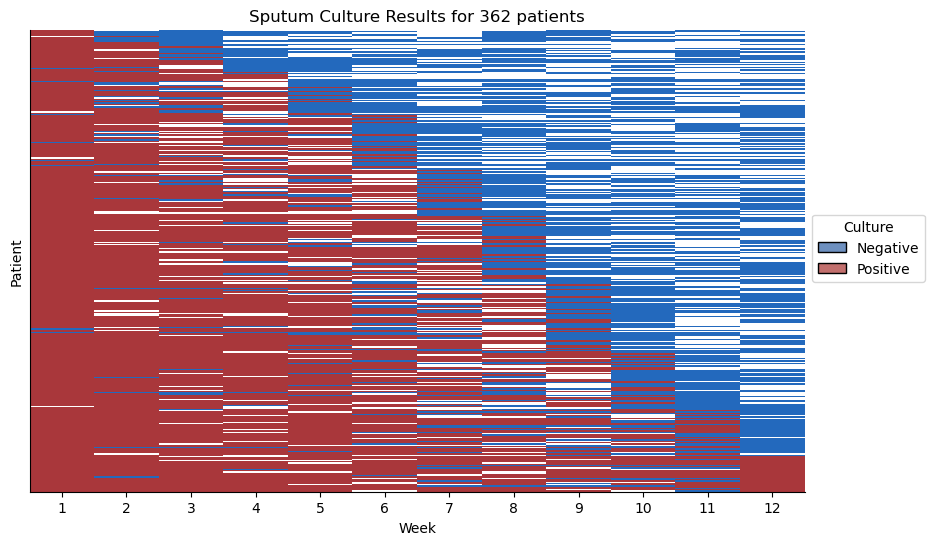

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

# sort the patients by the number of positive cultures they have, increasing
# sort_lst = pd.DataFrame(cultures_for_heatmap.sum(axis=1)).sort_values(0).index.values

sort_lst = df_TCC.query("pid in @final_keep_pids").sort_values(['TCC'], ascending=[True])['pid'].values

cultures_for_heatmap = cultures_for_heatmap.loc[sort_lst]

sns.heatmap(cultures_for_heatmap, cmap='vlag', cbar=False)

ax.set_yticks([])

plt.ylabel('Patient')
plt.xlabel('Week')

# Create a custom legend
legend_elements = [
    Patch(facecolor=sns.color_palette("vlag").as_hex()[0], edgecolor='black', label='Negative'),
    Patch(facecolor=sns.color_palette("vlag").as_hex()[-1], edgecolor='black', label='Positive')
]

ax.legend(
    handles=legend_elements, 
    title='Culture', 
    loc='upper left', 
    bbox_to_anchor=(1.01, 0.6),  # Adjust the position
    borderaxespad=0
)

plt.title(f"Sputum Culture Results for {cultures_for_heatmap.index.nunique()} patients")
sns.despine()
plt.savefig("figures/sputum_heatmap.svg", bbox_inches='tight')

# 1. Generate Helper Files for Culture Imputation

## 1a. Imputation file generated from the TRUST RedCap data that Sarah Thomson sent. Need to adjust a few columns (types, dates)

### 1b. Sputum and smear data -- extract from TRUST RedCap

In [16]:
def process_sputum_smear_data_for_imputation(df_TCC, df_combined_culture_results):
    '''
    Exclude TTP from the imputation because only positive uncontaminated samples have a TTP
    '''

    # keep only samples up to 12. Beyond that, those aren't actually weekly samples. Don't remove pids who are not valid for the TCC analysis
    # because they are valid for the poor outcome / relapse models
    df_smear_cultures = df_combined_culture_results.query("sample_num <= 12")

    # next, make the replacements:
    df_smear_cultures['result'] = df_smear_cultures['result'].replace('tb_positive_contaminated', 'tb_positive').replace('tb_negative_contaminated', np.nan)
    print(df_smear_cultures.result.unique())

    df_cultures = df_smear_cultures[['pid', 'sample_num', 'result']].rename(columns={'result': 'culture'})
    df_smear = df_smear_cultures[['pid', 'sample_num', 'smear_grade']]

    # pivot to matrix. Remove patients who are not valid from the TCC analysis from the sputum cultures matrix
    df_cultures = df_cultures.query("pid in @df_TCC.pid").pivot(index='pid', columns = 'sample_num', values = 'culture')
    df_smear = df_smear.pivot(index='pid', columns = 'sample_num', values = 'smear_grade')

    df_cultures.columns = [f"culture_{num}" for num in df_cultures.columns]
    df_smear.columns = [f"smear_grade_{num}" for num in df_smear.columns]

    return df_cultures, df_smear

In [17]:
df_cultures, df_smear = process_sputum_smear_data_for_imputation(df_TCC, df_combined_culture_results)

df_smear_positivity = np.where(df_smear > 0, 1, np.where(df_smear == 0, 0, np.nan))
df_smear_positivity = pd.DataFrame(df_smear_positivity, index=df_smear.index, columns=df_smear.columns.str.replace('grade', 'positivity'))

print(f"{len(df_cultures)} patients for the TCC analysis")
print(f"{len(df_smear_positivity)} patients in the smear dataframe")

# df_cultures.to_csv("processed_data/20241104_sputum.csv")
# df_smear.to_csv("processed_data/20241104_smear_grade.csv")
# df_smear_positivity.to_csv("processed_data/20241104_smear_positivity.csv")

['tb_positive' 'tb_negative' nan]
391 patients for the TCC analysis
452 patients in the smear dataframe


In [18]:
# update encodings on the full dataset
df_for_imputation = process_patient_metadata_better_encodings(df_full, TRUST_phenos, df_TTP_smear=df_TTP_smear, include_TTP=True)
print(df_for_imputation.pid.nunique())

# combine with smear grade at baseline and PLI predictions
df_for_imputation = df_for_imputation.merge(df_smear[['smear_grade_1']].reset_index(), how='left').merge(pli_predictions, on='pid', how='left')

# restrict to only patients with a valid TCC
df_for_TCC_imputation = df_for_imputation.query("pid in @df_TCC.pid")
print(df_for_TCC_imputation.query("pid in @df_TCC.pid").pid.nunique())

# this will only be used in the imputation for the outcomes model
df_TCC['TCC_longer_8weeks'] = (df_TCC['TCC'] > 8).astype(int)
df_for_imputation = df_for_imputation.merge(df_TCC[['pid', 'TCC_longer_8weeks']], how='left')

df_AUC = pd.read_csv("processed_data/drug_AUC_from_Marie.csv")

# already did this
# for i, row in df_AUC.iterrows():

#     if row['ID'] < 10:
#         df_AUC.loc[i, 'pid'] = f"T000{int(row['ID'])}"
#     elif row['ID'] < 100:
#         df_AUC.loc[i, 'pid'] = f"T00{int(row['ID'])}"
#     else:
#         df_AUC.loc[i, 'pid'] = f"T0{int(row['ID'])}"

df_for_imputation = df_for_imputation.merge(df_AUC, how='left', on='pid')

# save
df_for_imputation.to_csv("processed_data/data_for_imputation.csv", index=False)

452
391


# Survival Analysis

When culture_convert = 0, patients are right-censored, meaning that their culture conversion time is unknown because it's after the end of the study

# Variables for TCC Model:

Prefixes:

<ul>
    <li>screen = Screening visit</li>
    <li>bl = Baseline visit</li>
    <li>pk = Pharmacokinetics visit</li>
    <li>fu = Follow up (monthly)</li>
</ul>

<ul>
    <li>bl_years: Age as an integer</li>
    <li>bl_hiv: Binary variable, is the patient HIV+. Wait, bl_hiv is the same thing?</li>
    <li>bl_cd4: CD4 count, integer. </li>
    <li>bl_vl: Viral load result: float or "undetectable"</li>
    <li>bl_art: 1 = yes ART, 0 = no</li>
    <li>screen_sex: Binary, 1 = male, 2 = female</li>
    <li>Drug use (1 = +, 0 = -, 2 = indeterminate):</li>
        <ul>
            <li>bl_cannabis</li>
            <li>bl_meth</li>
            <li>bl_cocaine</li>
            <li>bl_opiates</li>
            <li>bl_amphetamine</li>
            <li>bl_mandrax: Methaqualone (most common I think?)</li>
        </ul>
    <li>bl_afbprog: 3 = +++, 2 = ++, 1 = +, 4 = scanty, 0 = No acid-fast bacillus, 5 = contaminated, 6 = Not done.</li>
    <li>bl_bmi: BMI</li>
    <li>pk_bac: blood alcohol concentration: float from 0-0.99</li>
    <li>audit1_2: alcohol consumption frequency: 0 = Never, 1 = ≤1/month, 2 = 2-4 times/month, 3 = 2-3 times/week, 4 = 4+times/week</li>
    <li>bl_weight: weight in kg</li>
    <li>bl_height: height in meters</li>
    <li>bl_ed</li>
    <li>bl_marital</li>
    <li>bl_housing</li>
    <li>bl_prison</li>
    <li>bl_prison2yr</li>
    <li>bl_prevtb: Binary variable has the person had active TB before this current episode</li>
    <li>bl_prevtboutcome: Treatment outcome for most recent previous bout of active TB: 1 = cured, 2 = treatment completed, 3 = treatment defaulted, 4 = treatment failure, 5 = moved, 6 = transferred out, 7 = not available</li>
</ul>


Chest X-Ray Findings:

<ul>
    <li>cxr_finding_chest_radiograph_1: 1 = Normal, 2 = Abnormal not compatible with TB, 3 = Abnormal may be compatible with TB, 4 = Abnormal highly suggestive of TB, 5 = Unknown or poor quality</li>
    <li>cxr_infiltrate_chest_radiograph_1: 1 = Yes Unilateral, 2 = Yes Bilateral, 3 = Yes Unknown, 0 = No, 4 = Unknown</li>
</ul>

For the following, the encoding is the same: 1 = Yes, 0 = No, 2 = Unknown

<ul>
    <li>cxr_miliary_chest_radiograph_1</li>
    <li>cxr_cavity_chest_radiograph_1</li>
    <li>cxr_lymph_chest_radiograph_1</li>
    <li>cxr_effusion_chest_radiograph_1</li>
    <li>cxr_granuloma_chest_radiograph_1</li>
</ul>

418 patients with any WGS samples
418 patients with uncontaminated WGS samples


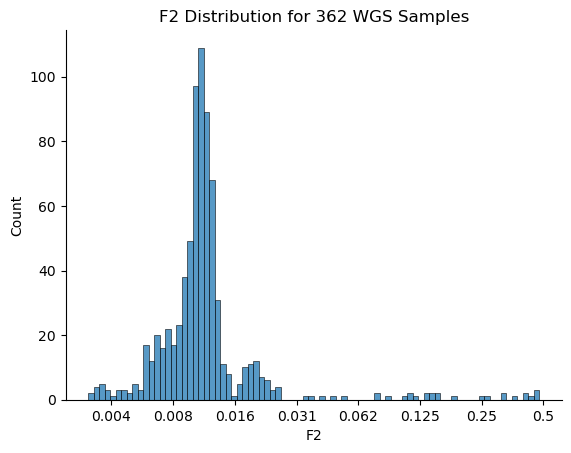

In [45]:
fig, ax = plt.subplots()

# get all the WGS samples, not just those collected at baseline
df_trust_patients_all = get_combined_patient_WGS_data_only("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/clinical_data/combined_patient_WGS_data.csv")

sns.histplot(data=df_trust_patients_all,
             x='F2',
             log_scale=2,
             ax=ax
            )

rounded_ticks = [np.round(text_obj.get_position()[0], 3) for text_obj in ax.get_xticklabels()]
ax.set_xticklabels(labels=rounded_ticks)

F2_vals_plot = df_trust_patients.query("pid in @final_keep_pids").sort_values(['pid', 'Original_ID']).drop_duplicates('pid', keep='first')

# plt.title(f"{F2_vals_plot.SampleID.nunique()} WGS Samples across {F2_vals_plot.pid.nunique()} pids")
plt.title(f"F2 Distribution for {F2_vals_plot.SampleID.nunique()} WGS Samples")
sns.despine()
plt.savefig("figures/F2_distribution.svg", bbox_inches='tight')

In [18]:
# st.spearmanr(df_trust_patients['total_adherence'], df_trust_patients['adherence_12week'])

In [19]:
# sns.scatterplot(data=df_trust_patients,
#                 x='total_adherence',
#                 y='adherence_12week'
#                )

# Dummy Encode Categorial Variables with >2 levels

## Find them first

In [20]:
# for col in cols_lst:
#     if df_model[col].nunique() > 2:
#         print(col)

In [21]:
# age and bmi are continuous values
# smear, ed, and audit1_baseline are already in proper ordinal format
# remaining need to be dummy encoded
# variables_for_dummy_encoding = ['bmi']#['Lineage'] #['bl_marital', 'bl_housing']

In [22]:
# for col in variables_for_dummy_encoding:

#     if col in df_model.columns and col in cols_lst:
        
#         df_dummies = pd.get_dummies(df_model.set_index('pid')[col], dtype=int, prefix=col)
    
#         del df_model[col]
    
#         # drop 1 for efficiency and to prevent perfect collinearity issues
#         df_model = df_model.merge(df_dummies.iloc[:, 1:], left_on='pid', right_index=True)
    
#         # remove from the list and add the new columns with the prefixes
#         cols_lst.remove(col)
#         cols_lst += list(df_model.columns[df_model.columns.str.startswith(col)])

# df_model.shape

# espR Indels

```bash
out_dir="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/espR_indels"

if [ ! -d $out_dir ]; then
    mkdir -p $out_dir
fi


for vcf_file in "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF/"*.vcf; do
    
    # Extract the base name of the VCF file without the .vcf extension
    base_name=$(basename "$vcf_file" .vcf)
    
    # Define the output file path
    output_file="$out_dir/$base_name.tsv"
        
    # Run bcftools filter and write to the output file. Query the upstream region up to the next gene upstream
    bcftools filter -i "POS >= 4323235 & POS <= 4323897" "$vcf_file" | bcftools view --types indels | SnpSift extractFields '-' POS REF ALT FILTER QUAL AF DP BQ MQ IC DC -e "" > "$output_file"

done
```

 ```bash
out_dir="/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/espA_indels"

if [ ! -d $out_dir ]; then
    mkdir -p $out_dir
fi


for vcf_file in "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF/"*.vcf; do
    
    # Extract the base name of the VCF file without the .vcf extension
    base_name=$(basename "$vcf_file" .vcf)
    
    # Define the output file path
    output_file="$out_dir/$base_name.tsv"
        
    # Run bcftools filter and write to the output file. Query the upstream region up to the next gene upstream
    bcftools filter -i "POS >= 4056376 & POS <= 4057732" "$vcf_file" | bcftools view --types indels | SnpSift extractFields '-' POS REF ALT FILTER QUAL AF DP BQ MQ IC DC -e "" > "$output_file"

done
```

In [11]:
# espA_indel_data = []

# vcf_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/espA_indels"

# fNames = glob.glob(f"{vcf_dir}/*.tsv")

# for fName in fNames:

#     try:
#         df_indels = pd.read_csv(fName, sep='\t')
    
#         if len(df_indels) > 0:
    
#             df_indels['SampleID'] = os.path.basename(fName).split('.')[0]
#             espA_indel_data.append(df_indels)
#     except:
#         print(f"Not finished {fName}")

# if len(espA_indel_data) > 0:
#     espA_indel_data = pd.concat(espA_indel_data).reset_index(drop=True)#.merge(df_trust_patients[['pid', 'SampleID']], on='SampleID')

#     # check to see if any samples have multiple indels
#     print(f"{espA_indel_data.SampleID.nunique()} samples have {len(espA_indel_data)} indels in espA")

# else:
#     print(f"There are no indels in espA in any sample")
#     del espA_indel_data

# # # add to df_trust_patients
# # df_trust_patients.loc[df_trust_patients['SampleID'].isin(espR_indel_data.SampleID), 'espR_indel'] = 1
# # df_trust_patients['espR_indel'] = df_trust_patients['espR_indel'].fillna(0)
# # df_trust_patients.loc[pd.isnull(df_trust_patients['Lineage']), 'espR_indel'] = np.nan

In [12]:
# in Roger's paper, they found that this single deletion was associated with LOWER espA expression
# if that is a significant effect, then would expect this mutation to occur in a person with a good outcome
# espA_indel_data

In [21]:
espR_indel_data = []

vcf_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/espR_indels"

fNames = glob.glob(f"{vcf_dir}/*.tsv")

for fName in fNames:

    try:
        df_indels = pd.read_csv(fName, sep='\t')
    
        if len(df_indels) > 0:
    
            df_indels['SampleID'] = os.path.basename(fName).split('.')[0]
            espR_indel_data.append(df_indels)
    except:
        print(f"Not finished {fName}")

espR_indel_data = pd.concat(espR_indel_data).reset_index(drop=True)#.merge(df_trust_patients[['pid', 'SampleID']], on='SampleID')

# check to see if any samples have multiple indels
print(f"{espR_indel_data.SampleID.nunique()} samples have {len(espR_indel_data)} indels in espR")

37 samples have 37 indels in espR


# Read in Imputed Datasets (N = 30) and compute TCC to compare to TCC derived from un-imputed data

## (expect some concordance)

For each imputed dataset,

1. Compute TCC
2. Keep only the predictors we want for the outcome models
3. Merge with microbial genetic data (F2, L1_L3 variables) and MICs (measured and predicted)
4. Fit Cox proportional hazards model

Then pool the results according to Rubin's rules: <a href="https://bookdown.org/mwheymans/bookmi/rubins-rules.html" target="_blank">Amazing Tutorial</a>

In [22]:
def compute_TCC_single_imputation(df_imputed, imp_num):

    df_single_imputation = df_imputed.loc[df_imputed['.imp']==imp_num]
        
    del df_single_imputation['.imp']
    del df_single_imputation['.id']

    # get the cultures only
    df_cultures = df_single_imputation[['pid'] + list(df_single_imputation.columns[df_single_imputation.columns.str.contains('culture_')])].melt(id_vars='pid')

    df_cultures['variable'] = df_cultures['variable'].str.replace('culture_', '').astype(int)

    # print(f"{sum(pd.isnull(df_cultures['value']))} NA cultures in imputation {imp_num}")

    # merge with smear grade because that's required for TCC computation and rename columns for TCC computation
    df_cultures = df_cultures.sort_values(['pid', 'variable']).rename(columns={'value': 'result', 'variable': 'sample_num'}).reset_index(drop=True).merge(df_combined_culture_results[['pid', 'sample_num', 'smear_grade']], on=['pid', 'sample_num'])

    # compute TCC
    df_TCC = pd.DataFrame(columns = ['pid', 'culture_convert_imputed', 'TCC_imputed']).set_index('pid')

    for pid in df_cultures.pid.unique():
        culture_convert, TCC = get_time_to_culture_conversion(df_cultures.query("pid==@pid"))
        df_TCC.loc[pid, :] = [culture_convert, TCC]

    return df_TCC.reset_index(), df_cultures

In [23]:
# read the imputed TCC results back in
df_TCC_imputed_all = pd.read_csv("imputation/TCC.csv").rename(columns={'culture_convert_imputed': 'culture_convert', 'TCC_imputed': 'TCC'})

df_reenroll = get_reenrolled_patients(df_full)

unique_cluster_dict = {}

cluster_num = 0

for i, row in df_reenroll.iterrows():
    
    if row['pid'] not in unique_cluster_dict.keys() and row['screen_prevpid'] not in unique_cluster_dict.keys():
        
        # add both pids (same person) to the dictionary
        unique_cluster_dict[row['pid']] = cluster_num
        unique_cluster_dict[row['screen_prevpid']] = cluster_num

        # then increment the cluster number
        cluster_num += 1

    else:
        if row['pid'] in unique_cluster_dict.keys():
            # get the existing number
            cluster_num_already_present = unique_cluster_dict[row['pid']]

            # add the new one with the same cluster number
            unique_cluster_dict[row['screen_prevpid']] = cluster_num_already_present
        else:
            cluster_num_already_present = unique_cluster_dict[row['screen_prevpid']]

            # same thing but using the cluster number determined from screen_prevpid
            unique_cluster_dict[row['pid']] = cluster_num_already_present


df_patient_clusters = pd.DataFrame(unique_cluster_dict, index=[0]).T.reset_index()
df_patient_clusters.columns = ['pid', 'cluster']

del df_patient_clusters

# add the unique patient identifiers (just integers)
df_TCC_imputed_all['unique_patient'] = df_TCC_imputed_all['pid'].map(unique_cluster_dict)

# increment the unique patient values for the rest of the pids, which have unique patients
start_cluster_num = np.max(list(unique_cluster_dict.values())) + 1

for i, row in df_TCC_imputed_all.iterrows():

    if pd.isnull(row['unique_patient']):
        if row['pid'] not in unique_cluster_dict.keys():
            df_TCC_imputed_all.loc[i, 'unique_patient'] = start_cluster_num
            unique_cluster_dict[row['pid']] = start_cluster_num
            start_cluster_num += 1
        else:
            df_TCC_imputed_all.loc[i, 'unique_patient'] = unique_cluster_dict[row['pid']]

assert sum(pd.isnull(df_TCC_imputed_all['unique_patient'])) == 0
print(f"{df_TCC_imputed_all['unique_patient'].nunique()} unique patients across {df_TCC_imputed_all['pid'].nunique()} pids")

# drop duplicates at each imputation, keeping the first patient
df_TCC_imputed_all = df_TCC_imputed_all.sort_values(['pid', 'unique_patient']).drop_duplicates(subset=['imp_num', 'unique_patient'], keep='first')

df_TCC_imputed_all['unique_patient'] = df_TCC_imputed_all['unique_patient'].astype(int)

377 unique patients across 391 pids


In [24]:
# df_reenroll = get_reenrolled_patients(df_full)

In [25]:
df_imputed = pd.read_csv("imputation/data_TCC.csv").drop_duplicates()
#.merge(df_trust_patients[['pid', 'F2']].drop_duplicates(subset='pid', keep='first'), how='left')

# these were determined to be outliers based on QC of the chest x-ray data, not from the predictions
# also Maha said that the error rates were comparable between outlier and non-outlier patients
pli_outliers = pli_predictions.query("outlier==1")['pid'].values
print(f"% lung involvement has {len(pli_outliers)} outliers")

df_imputed.loc[df_imputed['pid'].isin(pli_outliers), 'pli_outlier'] = 1
df_imputed['pli_outlier'] = df_imputed['pli_outlier'].fillna(0).astype(int)

# add to df_trust_patients
# pids_with_espR_indel = espR_indel_data.query("FILTER=='PASS' & AF > 0.75").merge(df_trust_patients[['pid', 'SampleID']], on='SampleID').pid.values
# df_imputed.loc[df_imputed['pid'].isin(pids_with_espR_indel), 'espR_indel'] = 1
# df_imputed['espR_indel'] = df_imputed['espR_indel'].fillna(0)

print(df_imputed.pid.nunique())

# df_TCC_imputed_all = []
# df_TCC_corrs = pd.DataFrame(columns = ['rho', 'pval', 'rho_convert_only', 'pval_convert_only'])

# for imp_num in df_imputed['.imp'].unique():
    
#     df_TCC_imputed, df_cultures_imputed = compute_TCC_single_imputation(df_imputed, imp_num)
    
#     df_TCC_imputed_plot = df_TCC_imputed.merge(df_TCC)
#     rho, pval = st.spearmanr(df_TCC_imputed_plot['TCC_imputed'], df_TCC_imputed_plot['TCC'])

#     rho_convert_only, pval_convert_only = st.spearmanr(df_TCC_imputed_plot.query("culture_convert_imputed==1 & culture_convert==1")['TCC_imputed'], df_TCC_imputed_plot.query("culture_convert_imputed==1 & culture_convert==1")['TCC'])

#     df_TCC_corrs.loc[imp_num, :] = [rho, pval, rho_convert_only, pval_convert_only]

#     df_TCC_imputed['imp_num'] = imp_num
#     df_TCC_imputed_all.append(df_TCC_imputed)

# df_TCC_imputed_all = pd.concat(df_TCC_imputed_all)
# df_TCC_imputed_all.to_csv("imputation/TCC.csv", index=False)

# df_full.dropna(subset='esp_reasonoth_end_of_study_parti').query("esp_reasonoth_end_of_study_parti.str.contains('|'.join(['resist', 'regimen']), case=False)")[['pid', 'to_studyto_treatment_outcome', 'to_comments_treatment_outcome', 'esp_reason_end_of_study_parti', 'esp_reasonoth_end_of_study_parti']]

# T0122 was diagnosed with MDR. T0137 died within 3 weeks of starting treatment, but their ESP reason says 'Changed to "liver-friendly regimen". No longer on first line drugs'
# they are removed by the TCC exclusion criterion because they died so soon and don't have enough cultures sampled.
exclude_pids_resistance = ['T0122', 'T0137']

# df_full.dropna(subset='to_comments_treatment_outcome').query("to_comments_treatment_outcome.str.contains('|'.join(['resist', 'regimen']), case=False)")[['pid', 'to_studyto_treatment_outcome', 'to_comments_treatment_outcome', 'esp_reason_end_of_study_parti', 'esp_reasonoth_end_of_study_parti']]

# T0322 says they were started on RHZE + levofloxacin
# T0330 is fine, says they had a positive month 5 culture and were RIF- and INH-sensitive
# T0355 started MDR regimen upon incarceration
exclude_pids_diff_regimen = ['T0322', 'T0355']

# add the household numbers
df_TCC_imputed_all = df_TCC_imputed_all.merge(df_full[['pid', 'household_num']])

# 3 of the above excluded pids are in here
df_TCC_imputed_all = df_TCC_imputed_all.query("pid not in @exclude_pids_resistance and pid not in @exclude_pids_diff_regimen").merge(df_trust_patients[['pid']].drop_duplicates()).reset_index(drop=True)
print(f"{df_TCC_imputed_all.pid.nunique()} unique patients across {df_TCC_imputed_all.household_num.nunique()} households")
df_imputed = df_imputed.query("pid in @df_TCC_imputed_all.pid")

% lung involvement has 47 outliers
391
362 unique patients across 334 households


In [23]:
# Prepare a list to collect survival functions from each imputation
survival_curves = []

# Fit Kaplan-Meier for each imputation and store survival function
for imp in df_TCC_imputed_all['imp_num'].unique():
    imputed_data = df_TCC_imputed_all.query("imp_num==@imp")

    kmf = lifelines.KaplanMeierFitter()
    kmf.fit(durations=imputed_data['TCC'], event_observed=imputed_data['culture_convert'])
    
    survival_curves.append(kmf.survival_function_.rename(columns={"KM_estimate": f"imp_{imp}"}))

# Combine all imputed survival functions into one DataFrame
df_survival = pd.concat(survival_curves, axis=1)

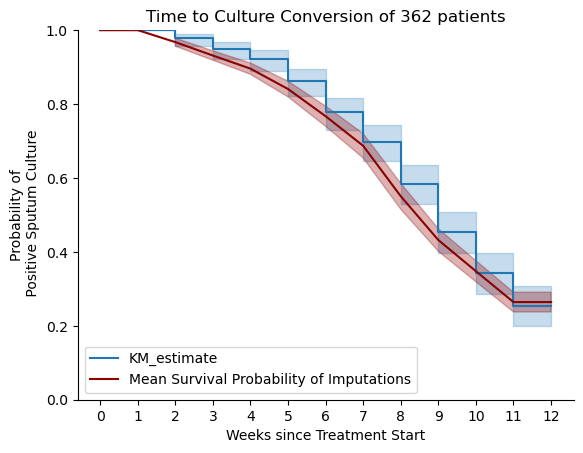

In [19]:
df_TCC = df_TCC.query("pid in @df_TCC_imputed_all.pid")

kmf_full_dataset = lifelines.KaplanMeierFitter()
kmf_full_dataset.fit(df_TCC['TCC'], event_observed=df_TCC['culture_convert'])

fig, ax = plt.subplots()

kmf_full_dataset.plot_survival_function()#show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5})
plt.ylim(0, 1)

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, df_TCC_imputed_all.TCC.max() + 1))

mean_survival = df_survival.mean(axis=1)
sd_survival = df_survival.std(axis=1)

# plot the mean survival probability at each week across the imputations
# plt.step(df_survival.index, mean_survival, label='KM Estimate of Imputed Datasets', where='post')
plt.plot(df_survival.index, mean_survival, label='Mean Survival Probability of Imputations', color='darkred')#, where='post')

# Calculate and plot the confidence interval using 1.96 * std for ~95% CI
ci_upper = mean_survival + 1.96 * sd_survival
ci_lower = mean_survival - 1.96 * sd_survival

# 'tab:blue'
plt.fill_between(df_survival.index, ci_lower, ci_upper, alpha=0.3, color='darkred')#, label='95% CI')

plt.title(f"Time to Culture Conversion of {df_TCC_imputed_all.pid.nunique()} patients")
plt.ylabel("Probability of\n Positive Sputum Culture") #
plt.xlabel("Weeks since Treatment Start")

plt.gca().get_legend().remove()
plt.legend()

sns.despine()
plt.savefig("figures/KM_estimate_TCC.svg", bbox_inches='tight')

In [20]:
kmf_full_dataset.median_survival_time_

9.0

In [21]:
# probability of being culture-positive at week 12
df_survival.iloc[:, 1:].loc[12].mean()

0.2651355159228745

In [25]:
# fig, ax = plt.subplots(figsize=(12, 10))

# ax = lifelines.plotting.plot_lifetimes(df_TCC['TCC'], event_observed=df_TCC['culture_convert'], ax=ax)

# # ax.vlines(10, 0, 30, lw=1, linestyles='--')
# ax.set_xlabel("weeks")
# ax.set_title("Births and deaths of our population, at $t=12$")

In [26]:
# # 0.78, 0.84
# df_TCC_corrs.rho.mean(), df_TCC_corrs.rho_convert_only.mean()

In [18]:
# df_TCC_imputed_imputation_average = df_TCC_imputed_all.rename(columns={'TCC': 'TCC_imputed', 'culture_convert': 'culture_convert_imputed'}).groupby(["pid"])[['TCC_imputed', 'culture_convert_imputed']].mean().astype(float)#.round().astype(int)

# for col in df_TCC_imputed_imputation_average.columns:
#     df_TCC_imputed_imputation_average[col] = np.round(df_TCC_imputed_imputation_average[col])
    
# # df_TCC_imputed_imputation_average = pd.DataFrame(df_TCC_imputed_all.groupby(["pid"])['TCC_imputed'].mean()).reset_index().merge(pd.DataFrame(df_TCC_imputed_all.groupby(["pid"])['culture_convert_imputed'].agg(pd.Series.mode)).reset_index())

# df_TCC_imputed_imputation_average = df_TCC_imputed_imputation_average.merge(df_TCC, on='pid')

In [19]:
# df_plot = df_TCC_imputed_imputation_average #df_TCC_imputed_plot#.query("~(culture_convert_imputed==1 & culture_convert==1)")

# sns.kdeplot(data=df_plot,
#             x='TCC_imputed',
#             y='TCC',
#             fill=True,
#             #hue='culture_convert'
#            )

# # plt.xlim(df_TCC_imputed_plot.TCC_imputed.min()-1, df_TCC_imputed_plot.TCC_imputed.max()+1)
# # plt.xlim(df_TCC_imputed_plot.TCC.min()-1, df_TCC_imputed_plot.TCC.max()+1)

# plt.title(f"{df_plot.pid.nunique()} patients")
# plt.ylabel("Raw TCC")
# plt.xlabel("Imputed TCC")

# sns.despine()
# plt.show()
# # plt.savefig(f"figures/TCC_imputed.svg", bbox_inches='tight')

In [26]:
cols_lst = [
            'screen_sex',
            'screen_years',
            # 'advanced_age',
            # 'bmi', # ordinal with 3 string groups
            'bl_bmi', # numerical BMI
            'fstrom1_baseline', # smoking yes or no
            'HIV_CD4',
            # 'bl_hiv', 
            'bl_prevtb',
            # 'smear_grade_1',
            # 'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            # 'predicted_label',
            'high_lung_involvement',
            # 'bilateral_infiltrates',
            # 'underweight',
            # 'total_adherence',
            # 'bl_inh_monoresistant',
            # 'inh_resistant',
            # 'espR_indel',
            'adherence_12week',
            # 'peth_value_baseline',
            # 'alcohol_use',
            # 'smoked_substance_use',
            # 'bl_mandrax', 
            'RIF_AUC',
            'INH_AUC',
            'EMB_AUC',
            'PZA_AUC',
            # 'cxr_finding_chest_radiograph_1', 
            # 'cxr_infiltrate_chest_radiograph_1', 
            # 'cxr_miliary_chest_radiograph_1', 
            'cxr_cavity_chest_radiograph_1',
            # 'cxr_lymph_chest_radiograph_1',
            # 'cxr_effusion_chest_radiograph_1',
            # 'cxr_granuloma_chest_radiograph_1',
            'F2'
           ]

stratify_covariates = ['cxr_cavity_chest_radiograph_1', 'smear_pos_no_contam_sputum_specimen_1', 'high_lung_involvement']

In [70]:
# continuous_cols = ['screen_years', 'bl_bmi', 'predicted_label', 'adherence_12week', 'total_adherence', 'RIF_AUC', 'F2', 'TTP_baseline']

# df_skew_coef = pd.DataFrame(columns = ['covariate', 'skew_coef'])
# i = 0

# for col in continuous_cols:
#     skew_coef = st.skew(df_imputed.merge(df_trust_patients[['pid', 'F2']])[col].dropna(), bias=True)
#     fig, ax = plt.subplots(1, 2, figsize=(10, 5))

#     plot_data = df_imputed.merge(df_trust_patients[['pid', 'F2']])[col]

#     if 'adherence' in col:
#         plot_data = 1 / plot_data
    
#     sns.histplot(plot_data, ax=ax[0])
#     sns.histplot(np.log2(plot_data), ax=ax[1])
    
#     plt.title(f"{col}: {np.round(skew_coef, 3)}")
#     sns.despine()
#     plt.show()

#     df_skew_coef.loc[i, :] = [col, skew_coef]
#     i += 1

# df_skew_coef['abs_skew_coef'] = np.abs(df_skew_coef['skew_coef'])

In [71]:
# df_skew_coef.sort_values("abs_skew_coef", ascending=False)

# Multivariate Models

## 0. Determine the model formulation by checking the proportional hazards function

In [28]:
df_test_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(df_trust_patients,
                                                                                                  df_pred_combined,
                                                                                                   TRUST_phenos,
                                                                                                   df_imputed,
                                                                                                  df_TCC_imputed_all,
                                                                                                  cols_lst,
                                                                                                  event_col = 'culture_convert',
                                                                                                  time_col = 'TCC',
                                                                                                  exclude_resistance=False,
                                                                                                  MIC_type='none',
                                                                                                  binarize_MICs=False,
                                                                                                  tb_deaths_only=False,
                                                                                                  invert_OR=True,
                                                                                                  include_interactions=False,
                                                                                                  penalize_model=False,
                                                                                                  original_dataset_only=False,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                  #non_linear_term_variables=['predicted_label'],
                                                                                                 )

    362 total pids


In [29]:
df_violating_covariates = []

for model_idx in range(len(cph_models_imputations)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_samples_imputations[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)

In [30]:
df_violating_covariates.query("p <= 0.05")

,covariate,p,imp_num
9,bl_prevtb,0.022207,6
9,bl_prevtb,0.034858,8
9,bl_prevtb,0.034879,11
3,HIV_Low_CD4,0.042281,22
3,HIV_Low_CD4,0.013396,27


In [21]:
# model_idx = -1

# # for model_idx in range(len(df_samples_imputations)):

# cph_models_imputations[model_idx].check_assumptions(df_samples_imputations[model_idx][['unique_patient', 'culture_convert', 'TCC'] + ['HIV_Low_CD4', 'HIV_High_CD4'] + list(set(cols_lst) - set(['HIV_CD4']))], 
#                                                     p_value_threshold=0.01,
#                                                     raise_on_fail=False,
#                                                     show_plots=True
#                                                    )

In [47]:
# df_check_stratify_vars = df_imputed.loc[df_imputed['.imp']==30].merge(df_TCC_imputed_all.query("imp_num==30")[['pid', 'TCC', 'culture_convert']], on='pid').merge(TRUST_phenos, on='pid')

# df_check_stratify_vars['RIF_R'] = (df_check_stratify_vars['RIF_lower_bound'] >= 0.5).astype(int)
# df_check_stratify_vars['INH_R'] = (df_check_stratify_vars['INH_lower_bound'] >= 0.2).astype(int)
# df_check_stratify_vars['EMB_R'] = (df_check_stratify_vars['EMB_lower_bound'] >= 5).astype(int)
# df_check_stratify_vars['PZA_R'] = (df_check_stratify_vars['PZA_lower_bound'] >= 100).astype(int)

In [ ]:
# binary_resistance_variables = ['RIF_R', 'INH_R', 'EMB_R', 'PZA_R']
# labels_lst = ['Rifampicin R', 'Isoniazid R', 'Ethambutol R', 'Pyrazinamide R']
# labels_dict = dict(zip(binary_resistance_variables, labels_lst))

# color_dict = dict(zip([0, 1], sns.color_palette().as_hex()))

# for variable in binary_resistance_variables:
    
#     if sum(df_check_stratify_vars[variable]) > 0:

#         fig, ax = plt.subplots()

#         # sort so that 0 is plotted before 1
#         for group in np.sort(df_check_stratify_vars[variable].unique()):
        
#             df_single_group = df_check_stratify_vars.query(f"{variable}==@group")
#             kmf.fit(df_single_group['TCC'], event_observed=df_single_group['culture_convert'], label=group)
#             kmf.plot_survival_function(ax=ax, show_censors=False, color=color_dict[group], censor_styles={"marker": "+", "ms": 8, "mew": 0.5})#, label=f"{labels_dict[group]} = {len(df_single_group)}")
    
#             plt.legend(title=labels_dict[variable])
    
#         logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_check_stratify_vars.query(f"{variable}==1")['TCC'], 
#                                                                   durations_B=df_check_stratify_vars.query(f"{variable}==0")['TCC'], 
#                                                                   event_observed_A=df_check_stratify_vars.query(f"{variable}==1")['culture_convert'], 
#                                                                   event_observed_B=df_check_stratify_vars.query(f"{variable}==0")['culture_convert'],
#                                                                  )
    
#         print(f"{labels_dict[variable]}: χ^2 = {logRank_test_results.test_statistic}, p = {logRank_test_results.p_value}")
    
#         sns.despine()
#         plt.title(f"Time to Culture Conversion of {df_check_stratify_vars.pid.nunique()} patients")
#         plt.ylabel("Probability of\n Positive Sputum Culture") #
#         plt.xlabel("Weeks since Treatment Start")
#         sns.despine()

Cavitation: χ^2 = 30.74301873563115, p = 2.945616979227551e-08
> 20% Lung Affected: χ^2 = 29.841643603147183, p = 4.688131553764546e-08
Smear Positivity: χ^2 = 20.97865881939683, p = 4.6442802936031545e-06


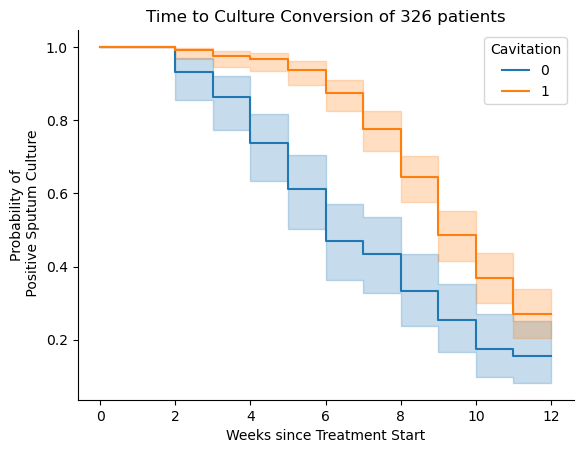

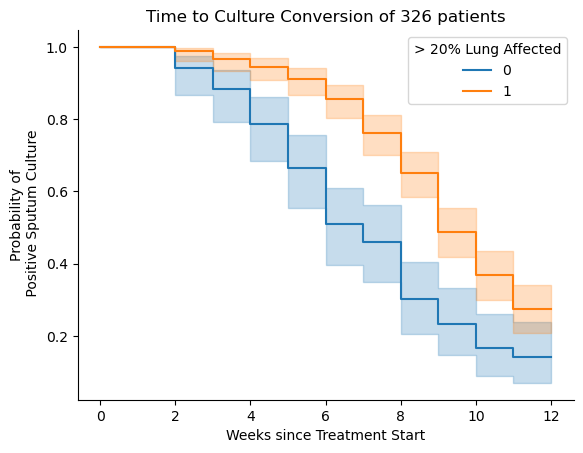

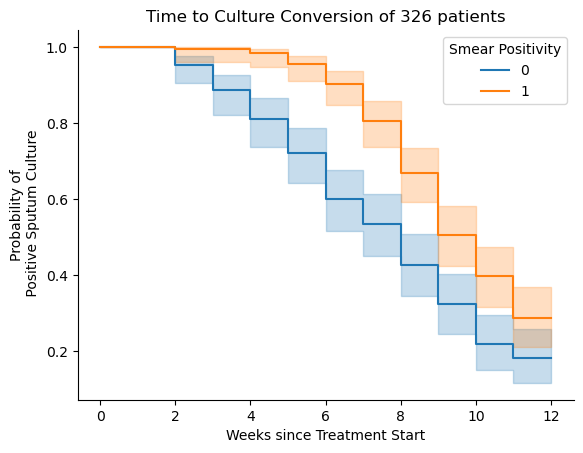

In [31]:
imp_num = 0
df_check_stratify_vars = df_imputed.loc[df_imputed['.imp']==imp_num].merge(df_TCC_imputed_all.query("imp_num==@imp_num")[['pid', 'TCC', 'culture_convert']], on='pid')
df_check_stratify_vars['high_lung_involvement'] = (df_check_stratify_vars['predicted_label'] > 20)
df_check_stratify_vars = df_check_stratify_vars.dropna(subset=stratify_covariates)
df_check_stratify_vars['high_lung_involvement'] = df_check_stratify_vars['high_lung_involvement'].astype(int)

labels_lst = ['Cavitation', '> 20% Lung Affected', 'Smear Positivity']
labels_dict = dict(zip(stratify_covariates, labels_lst))

color_dict = dict(zip([0, 1], sns.color_palette().as_hex()))

for variable in stratify_covariates:

    fig, ax = plt.subplots()
    
    df_check_stratify_vars[variable] = df_check_stratify_vars[variable].astype(int)

    # sort so that 0 is plotted before 1
    for group in np.sort(df_check_stratify_vars[variable].unique()):
    
        df_single_group = df_check_stratify_vars.query(f"{variable}==@group")
        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(df_single_group['TCC'], event_observed=df_single_group['culture_convert'], label=group)
        kmf.plot_survival_function(ax=ax, show_censors=False, color=color_dict[group], censor_styles={"marker": "+", "ms": 8, "mew": 0.5})#, label=f"{labels_dict[group]} = {len(df_single_group)}")

        plt.legend(title=labels_dict[variable])

    logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_check_stratify_vars.query(f"{variable}==1")['TCC'], 
                                                              durations_B=df_check_stratify_vars.query(f"{variable}==0")['TCC'], 
                                                              event_observed_A=df_check_stratify_vars.query(f"{variable}==1")['culture_convert'], 
                                                              event_observed_B=df_check_stratify_vars.query(f"{variable}==0")['culture_convert'],
                                                             )

    print(f"{labels_dict[variable]}: χ^2 = {logRank_test_results.test_statistic}, p = {logRank_test_results.p_value}")

    sns.despine()
    plt.title(f"Time to Culture Conversion of {df_check_stratify_vars.pid.nunique()} patients")
    plt.ylabel("Probability of\n Positive Sputum Culture") #
    plt.xlabel("Weeks since Treatment Start")
    sns.despine()
    plt.savefig(f"figures/KM_estimate_TCC_stratified_{labels_dict[variable]}.svg", bbox_inches='tight')

# 1.1 Univariate Association Models

In [74]:
# stratify_covariates = ['cxr_cavity_chest_radiograph_1', 'high_lung_involvement', 'smear_pos_no_contam_sputum_specimen_1']
# MIC_cols_lst = [f"{drug}_midpoint" for drug in ['RIF', 'INH', 'EMB']] + [f"{drug}_pred_MIC" for drug in drugs_lst]

# df_univar_pvals_TCC = []

# for covar in cols_lst:

#     # need to stratify by these variables
#     if covar not in stratify_covariates:

#         print(f"Testing {covar}")
    
#         df_test_results, _, _ = fit_cox_models_all_imputations(df_trust_patients,
#                                                               df_pred_combined,
#                                                                TRUST_phenos,
#                                                                df_imputed,
#                                                               df_TCC_imputed_all,
#                                                               [covar] + stratify_covariates, # make sure to include stratify_covariates here as well otherwise it will fail
#                                                               event_col = 'culture_convert',
#                                                               time_col = 'TCC',
#                                                               exclude_resistance=False,
#                                                               MIC_type='none',
#                                                               binarize_MICs=False,
#                                                               tb_deaths_only=False,
#                                                               include_drugs=[],
#                                                               invert_OR=True,
#                                                               include_interactions=False,
#                                                               penalize_model=False,
#                                                               original_dataset_only=False,
#                                                               stratify_variables=stratify_covariates,
#                                                                # cluster_col='household_num'
#                                          )


#         # could be two because of the HIV CD4 categorical variable
#         assert len(df_test_results) <= 2

#         df_univar_pvals_TCC.append(df_test_results[['covariate', 'coef_pooled', 'pval']])

# # # then test the MICs and binary resistance variables
# # for covar in MIC_cols_lst:

# #     drug = covar.split('_')[0]
# #     print(f"Testing {covar}, drug = {drug}")

# #     if '_midpoint' in covar:
# #         MIC_type = 'measured'
# #     elif '_pred_MIC' in covar:
# #         MIC_type = 'predicted'
# #     else:
# #         raise ValueError(f"{covar} is neither a predicted nor a measured MIC")

# #     df_test_results, _, _ = fit_cox_models_all_imputations(df_trust_patients,
# #                                                           df_pred_combined,
# #                                                            TRUST_phenos,
# #                                                            df_imputed,
# #                                                           df_TCC_imputed_all,
# #                                                           [covar] + stratify_covariates,
# #                                                           event_col = 'culture_convert',
# #                                                           time_col = 'TCC',
# #                                                           exclude_resistance=False,
# #                                                           MIC_type=MIC_type,
# #                                                           binarize_MICs=False,
# #                                                           tb_deaths_only=False,
# #                                                           include_drugs=[drug],
# #                                                           invert_OR=True,
# #                                                           include_interactions=False,
# #                                                           penalize_model=False,
# #                                                           original_dataset_only=False,
# #                                                           stratify_variables=stratify_covariates,
# #                                      )

# #     df_univar_pvals_TCC.append(df_test_results[['covariate', 'coef_pooled', 'pval']])

# # for covar in MIC_cols_lst:

# #     covar = covar + '_resistant'

# #     drug = covar.split('_')[0]
# #     print(f"Testing {covar}, drug = {drug}")

# #     if '_midpoint' in covar:
# #         MIC_type = 'measured'
# #     elif '_pred_MIC' in covar:
# #         MIC_type = 'predicted'
# #     else:
# #         raise ValueError(f"{covar} is neither a predicted nor a measured MIC")

# #     df_test_results, _, _ = fit_cox_models_all_imputations(df_trust_patients,
# #                                                           df_pred_combined,
# #                                                            TRUST_phenos,
# #                                                            df_imputed,
# #                                                           df_TCC_imputed_all,
# #                                                           [covar] + stratify_covariates,
# #                                                           event_col = 'culture_convert',
# #                                                           time_col = 'TCC',
# #                                                           exclude_resistance=False,
# #                                                           MIC_type=MIC_type,
# #                                                           binarize_MICs=True,
# #                                                           tb_deaths_only=False,
# #                                                           include_drugs=[drug],
# #                                                           invert_OR=True,
# #                                                           include_interactions=False,
# #                                                           penalize_model=False,
# #                                                           original_dataset_only=False,
# #                                                           stratify_variables=stratify_covariates,
# #                                      )

# #     df_univar_pvals_TCC.append(df_test_results[['covariate', 'coef_pooled', 'pval']])
    
# pd.concat(df_univar_pvals_TCC).rename(columns={'coef_pooled': 'coef'}).to_csv("./model_results/univariate_results_TCC_with_stratification.csv", index=False)
df_univar_pvals_TCC = pd.read_csv("./model_results/univariate_results_TCC_with_stratification.csv")

Testing screen_sex
    362 total pids
Testing screen_years
    362 total pids
Testing bl_bmi
    362 total pids
Testing fstrom1_baseline
    362 total pids
Testing HIV_CD4
    362 total pids
Testing bl_prevtb
    362 total pids
Testing diabetes
    362 total pids
Testing adherence_12week
    362 total pids
Testing RIF_AUC
    362 total pids
Testing INH_AUC
    362 total pids
Testing EMB_AUC
    362 total pids
Testing PZA_AUC
    362 total pids
Testing F2
    362 total pids


## 1.2. LRT to prune the patient covariates from the model

In [32]:
# df_LRT_pvals_TCC = pd.DataFrame(columns = ['pval'])

# for covar in cols_lst:

#     # need to stratify by these variables
#     if covar not in stratify_covariates:

#         print(f"Testing {covar}")
    
#         pval = run_LRT_single_predictor(covar, 
#                                         df_trust_patients,
#                                         df_pred_combined,
#                                         TRUST_phenos,
#                                         df_imputed, 
#                                         df_TCC_imputed_all, 
#                                         cols_lst, 
#                                         event_col='culture_convert',
#                                         time_col='TCC',
#                                         MIC_type='none',
#                                         stratify_variables=stratify_covariates,
#                                        )
        
#         df_LRT_pvals_TCC.loc[covar, 'pval'] = pval

# df_LRT_pvals_TCC.reset_index().rename(columns={'index': 'covariate'}).to_csv("./model_results/LRT_results_TCC_with_stratification.csv", index=False)
df_LRT_pvals_TCC = pd.read_csv("./model_results/LRT_results_TCC_with_stratification.csv")

## 2. Fit a final patient covariate model with only the ones selected from the LRT, then add MICs to that

In [33]:
final_patient_predictors = list(df_LRT_pvals_TCC.query("pval <= 0.2")['covariate'].values)

# add BMI as an adjustment for AUC? Because the drugs are dosed by weight, heavier individuals have higher AUC
final_patient_predictors  = final_patient_predictors + stratify_covariates# + ['bl_bmi']

print(final_patient_predictors)

['screen_years', 'RIF_AUC', 'INH_AUC', 'PZA_AUC', 'cxr_cavity_chest_radiograph_1', 'smear_pos_no_contam_sputum_specimen_1', 'high_lung_involvement']


In [34]:
df_test_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(df_trust_patients,
                                                                                                  df_pred_combined,
                                                                                                   TRUST_phenos,
                                                                                                   df_imputed,
                                                                                                  df_TCC_imputed_all,
                                                                                                  final_patient_predictors,
                                                                                                  event_col = 'culture_convert',
                                                                                                  time_col = 'TCC',
                                                                                                  exclude_resistance=False,
                                                                                                  MIC_type='none',
                                                                                                  binarize_MICs=False,
                                                                                                  tb_deaths_only=False,
                                                                                                  invert_OR=True,
                                                                                                  include_interactions=False,
                                                                                                  penalize_model=False,
                                                                                                  original_dataset_only=False,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 )


df_violating_covariates = []

for model_idx in range(len(cph_models_imputations)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_samples_imputations[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)

    362 total pids


In [35]:
# one instance, so I think it's okay
df_violating_covariates.query("p <= 0.05")

,covariate,p,imp_num
3,screen_years,0.021944,8


In [48]:
exclude_resistance_lst = [0]
MIC_type_lst = ['predicted', 'measured']

param_grid = list(itertools.product(exclude_resistance_lst, MIC_type_lst, drugs_lst + [drugs_lst] + [['RIF', 'INH', 'EMB']]))

# If you prefer the result as a list of dictionaries (one for each combination):
param_grid_dicts = [
    {
     'exclude_resistance': exclude_resistance,
     'MIC_type': MIC_type,
     'include_drugs_lst': [drug] if type(drug) != list else drug # try each drug individuallly and also all of them together
    }
    for exclude_resistance, MIC_type, drug in param_grid
]

len(param_grid_dicts)

12

In [51]:
# df_TCC_model_final = []

# for i, params_lst in enumerate(param_grid_dicts):

#     print(f"Model {i+1}")

#     # skip cases where MIC = measured and PZA is included because it drops the sample size
#     if params_lst['MIC_type'] == 'measured' and 'PZA' in params_lst['include_drugs_lst']:
#         print("    Skipping model")

#     else:
# #         # only include drug AUCs if the MIC is included
# #         drug_AUC_lst = [f"{drug}_AUC" for drug in params_lst['include_drugs_lst']]
# #         print(f"    {drug_AUC_lst}")
        
#         df_test_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(df_trust_patients,
#                                                                                                           df_pred_combined,
#                                                                                                            TRUST_phenos,
#                                                                                                            df_imputed,
#                                                                                                           df_TCC_imputed_all,
#                                                                                                           final_patient_predictors,# + drug_AUC_lst,
#                                                                                                           event_col = 'culture_convert',
#                                                                                                           time_col = 'TCC',
#                                                                                                           exclude_resistance=params_lst['exclude_resistance'],
#                                                                                                           MIC_type=params_lst['MIC_type'],
#                                                                                                           binarize_MICs=False,
#                                                                                                           tb_deaths_only=False,
#                                                                                                           include_drugs=params_lst['include_drugs_lst'],
#                                                                                                           invert_OR=True,
#                                                                                                           include_interactions=False,
#                                                                                                           penalize_model=False,
#                                                                                                           original_dataset_only=False,
#                                                                                                           stratify_variables=stratify_covariates,
#                                                                                      )

#         for model_idx in range(len(cph_models_imputations)):

#             df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], 
#                                                                                     df_samples_imputations[model_idx], 
#                                                                                     time_transform='rank').summary.reset_index().rename(columns={'index': 'covariate'})
        
#             violating_covariates = df_proportional_hazards.query("p <= 0.01").covariate.values

#             if len(violating_covariates) > 0:
#                 print(f"Predictors {violating_covariates} violated the proportional hazards assumptions")
                
#         df_test_results['exclude_resistance'] = params_lst['exclude_resistance']
#         df_test_results['MIC_type'] = params_lst['MIC_type']
#         df_test_results['include_drugs'] = ','.join(params_lst['include_drugs_lst'])
#         df_test_results['num_pids'] = df_samples_imputations[0]['pid'].nunique()
            
#         df_TCC_model_final.append(df_test_results)

# df_TCC_model_final = pd.concat(df_TCC_model_final)

# # annotate significance
# df_TCC_model_final.loc[(df_TCC_model_final["pval"] <= 0.05), 'significant'] = 1
# df_TCC_model_final.to_csv("./model_results/TCC_with_stratification.csv", index=False)

In [52]:
df_TCC_model_final.query("pval <= 0.05").covariate.unique()

array(['RIF_AUC', 'screen_years'], dtype=object)

In [54]:
df_TCC_model_final = pd.read_csv("./model_results/TCC_with_stratification.csv")
print(df_TCC_model_final.query("significant==1").covariate.unique())

OR_col = 'HR_TCC_assoc'

# transform some hazard ratios for interpretability
# 1. Age: make it for each decade
# 2. RIF AUC: by 10. It ranges from 0 - 120, but mostly 0-70. Nah, the confidence interval looks weird.
# 3: % lung involvement: by 10 also. Ranges from 0-80. Nah, makes it huge. Stick to 1%

for col in ['screen_years']:# + list(df_TCC_model_final.query("covariate.str.endswith('_AUC')").covariate.unique()):#, 'RIF_AUC']:

    df_TCC_model_final.loc[df_TCC_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_TCC_model_final.loc[df_TCC_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

# MIC HRs should be transformed to per 0.01 µg/mL for RIF, INH, and EMB and per 10 µg/mL for PZA  
# transform the confidence intervals for the predicted MICs to per 0.01, as they did in the NEJM paper
for col in df_TCC_model_final.query("covariate.str.endswith('_midpoint') | covariate.str.endswith('_pred_MIC')").covariate.unique():

    multiply_factor = 0.1
    print(col, multiply_factor)
    
    df_TCC_model_final.loc[df_TCC_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_TCC_model_final.loc[df_TCC_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**multiply_factor

['RIF_AUC' 'screen_years']
RIF_pred_MIC 0.1
INH_pred_MIC 0.1
EMB_pred_MIC 0.1
PZA_pred_MIC 0.1
RIF_midpoint 0.1
INH_midpoint 0.1
EMB_midpoint 0.1


In [55]:
df_TCC_model_final.query("MIC_type=='predicted' & include_drugs=='RIF,INH,EMB,PZA'").covariate.unique()

array(['EMB_pred_MIC', 'INH_AUC', 'INH_pred_MIC', 'PZA_AUC',
       'PZA_pred_MIC', 'RIF_AUC', 'RIF_pred_MIC', 'screen_years'],
      dtype=object)

In [78]:
df_TCC_model_final.query("pval <= 0.05").covariate.unique()

array(['RIF_AUC', 'screen_years'], dtype=object)

In [59]:
label_dict = {'RIF_pred_MIC': 'Predicted RIF MIC',
            'INH_pred_MIC': 'Predicted INH MIC',
            'EMB_pred_MIC': 'Predicted EMB MIC',
            'PZA_pred_MIC': 'Predicted PZA MIC',
            'RIF_AUC': 'Rifampicin PK AUC',
            'INH_AUC': 'Isoniazid PK AUC',
            'EMB_AUC': 'Ethambutol PK AUC',
            'PZA_AUC': 'Pyrazinamide PK AUC',
            'screen_years': 'Age',
              'RIF_midpoint': 'Measured RIF MIC',
              'INH_midpoint': 'Measured INH MIC',
              'EMB_midpoint': 'Measured EMB MIC',
              'PZA_midpoint': 'Measured PZA MIC'
           }

In [80]:
forest_plot(df_TCC_model_final.query("MIC_type=='predicted' & include_drugs=='RIF,INH,EMB,PZA'"), label_dict, val_col='HR_TCC_assoc', alpha=0.05, saveName="./figures/TCC_predicted_MIC.svg")

In [81]:
forest_plot(df_TCC_model_final.query("MIC_type=='measured' & include_drugs=='RIF,INH,EMB'"), label_dict ,val_col='HR_TCC_assoc', alpha=0.05, saveName="./figures/TCC_measured_MIC.svg")

# Post Model-Fitting Analyses

In [20]:
df_test_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(df_trust_patients,
                                                                                                  df_pred_combined,
                                                                                                   TRUST_phenos,
                                                                                                   df_imputed,
                                                                                                  df_TCC_imputed_all,
                                                                                                  final_patient_predictors,
                                                                                                  event_col = 'culture_convert',
                                                                                                  time_col = 'TCC',
                                                                                                  exclude_resistance=False,
                                                                                                  MIC_type='predicted',
                                                                                                  binarize_MICs=False,
                                                                                                  tb_deaths_only=False,
                                                                                                  include_drugs=drugs_lst,
                                                                                                  invert_OR=True,
                                                                                                  include_interactions=False,
                                                                                                  penalize_model=False,
                                                                                                  original_dataset_only=False,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 cluster_col='household_num'
                                                                             )

    362 total pids


In [21]:
df_plot = combine_survival_probabilities_across_imputations(df_samples_imputations, cph_models_imputations, stratify_covariates)

8 unique condition combinations


In [22]:
def trapezoidal_rule(df_single_group):

    df_single_group = df_single_group.sort_values("Week").reset_index(drop=True)
    
    h = df_single_group['Week'].max() / len(df_single_group)

    total_area = 0

    for i, row in df_single_group.iterrows():

        if i > 0:
            # survival probabilities must be monotonically decreasing
            assert row['Mean'] <= df_single_group['Mean'].values[i-1]
            total_area += 0.5 * h * (row['Mean'] + df_single_group['Mean'].values[i-1])

    return total_area

In [23]:
def plot_baseline_survival_curve(df_plot, select_params=None, plot_ci=False, saveName=None):

    if select_params is not None:
        df_plot = df_plot.query("variable in @select_params")

    df_trapezoidal_areas = pd.DataFrame(columns = ['group', 'area'])
    i = 0
    
    for group in df_plot['variable'].unique():
    
        df_trapezoidal_areas.loc[i, :] = [group, trapezoidal_rule(df_plot.loc[df_plot['variable']==group])]
        i += 1

    # plot in order of decreasing TCC for ease of matching colors in the legend order
    plot_order = df_trapezoidal_areas.sort_values("area", ascending=False)['group'].values

    # plot in order of decreasing TCC for ease of matching colors in the legend order
    # plot_order = df_plot.groupby('variable')['Mean'].median().sort_values(ascending=False).index.values

    fig, ax = plt.subplots()
    
    # plot the mean survival probability at each week across the imputations
    sns.lineplot(data=df_plot,
                 x='Week',
                 y='Mean',
                 hue='variable',
                 hue_order=plot_order,
                 # palette='colorblind'
                )

    colors = sns.color_palette("tab10").as_hex()
    
    plt.title("Survival Probabilities across Stratified Groups")
    plt.ylabel('Proportion Sputum Positive')

    if plot_ci:

        # Calculate and plot the confidence interval using 1.96 * std for ~95% CI
        df_plot['CI_lower'] = df_plot['Mean'] - 1.96 * df_plot['SD']
        df_plot['CI_upper'] = df_plot['Mean'] + 1.96 * df_plot['SD']
        
        for i, group in enumerate(plot_order):
            df_plot_single_group = df_plot.query("variable==@group").sort_values("Week")
            plt.fill_between(df_plot_single_group.Week, df_plot_single_group['CI_lower'], df_plot_single_group['CI_upper'], alpha=0.3, color=colors[i])

    # Set x-axis ticks to show all integers
    ax.set_xticks(range(0, int(df_plot.Week.max()) + 1))
    plt.ylim(0, 1)
    
    ax.legend(loc='upper center', bbox_to_anchor=(1.25, 1.1), fontsize=10)
    
    sns.despine()

    if saveName is not None:
        plt.savefig(saveName, bbox_inches='tight')
        # plt.close()
    else:
        plt.show()

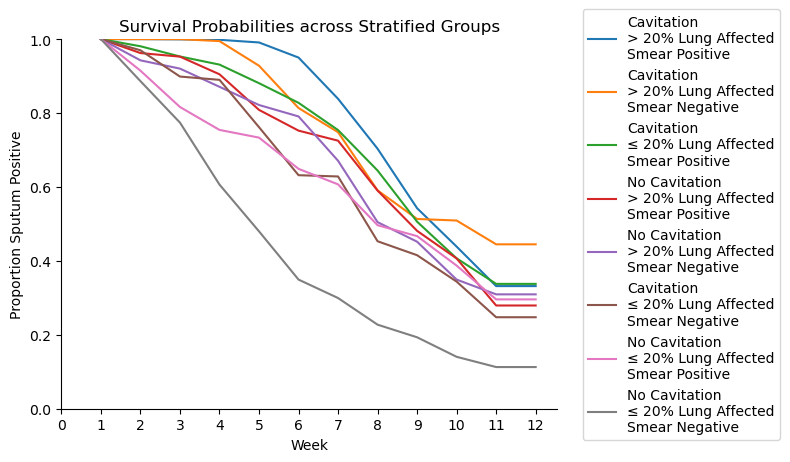

In [24]:
plot_baseline_survival_curve(df_plot, saveName="./figures/TCC_predicted_MIC_stratified_survival_curves.svg")

In [39]:
# select_params = ['No Cavitation\n≤ 20% Lung Affected\nSmear Negative', # all 0s
#                  'No Cavitation\n≤ 20% Lung Affected\nSmear Positive', # low lung involvement = 1 only, expect best outcomes
#                  'Cavitation\n> 20% Lung Affected\nSmear Positive'
#                 ]

# plot_baseline_survival_curve(df_plot, 
#                              select_params=select_params, 
#                              plot_ci=True, 
#                              saveName="./figures/TCC_predicted_MIC_stratified_survival_curves_smear_comparison_low_lung_involvement.svg"
#                             )

In [40]:
# select_params = ['No Cavitation\n> 20% Lung Affected\nSmear Negative', # all 0s
#                  'No Cavitation\n> 20% Lung Affected\nSmear Positive', # low lung involvement = 1 only, expect best outcomes,
#                  'Cavitation\n> 20% Lung Affected\nSmear Positive'
#                 ]

# plot_baseline_survival_curve(df_plot, 
#                              select_params=select_params, 
#                              plot_ci=True, 
#                              saveName="./figures/TCC_predicted_MIC_stratified_survival_curves_smear_comparison_high_lung_involvement.svg"
#                             )

In [41]:
# select_params = ['No Cavitation\n≤ 20% Lung Affected\nSmear Negative', # all 0s
#                  'Cavitation\n≤ 20% Lung Affected\nSmear Negative', # low lung involvement = 1 only, expect best outcomes,
#                  'Cavitation\n> 20% Lung Affected\nSmear Positive'
#                 ]

# plot_baseline_survival_curve(df_plot, 
#                              select_params=select_params, 
#                              plot_ci=True, 
#                              saveName="./figures/TCC_predicted_MIC_stratified_survival_curves_cavitation_comparison_low_lung_involvement.svg"
#                             )

In [42]:
# select_params = ['No Cavitation\n> 20% Lung Affected\nSmear Negative', # all 0s
#                  'Cavitation\n> 20% Lung Affected\nSmear Negative', # low lung involvement = 1 only, expect best outcomes,
#                  'Cavitation\n> 20% Lung Affected\nSmear Positive'
#                 ]

# plot_baseline_survival_curve(df_plot, 
#                              select_params=select_params, 
#                              plot_ci=True, 
#                              saveName="./figures/TCC_predicted_MIC_stratified_survival_curves_cavitation_comparison_high_lung_involvement.svg"
#                             )

In [43]:
# # cavitation + smear positive + ≤ 20% lung vs. no cavitation + smear negative + > 20% lung
# select_params = [
#                 # 'No Cavitation\n> 20% Lung Affected\nSmear Negative',
#                  'Cavitation\n≤ 20% Lung Affected\nSmear Positive',
#                  'No Cavitation\n> 20% Lung Affected\nSmear Negative'
#                 ]

# plot_baseline_survival_curve(df_plot, 
#                              select_params=select_params, 
#                              plot_ci=True, 
#                              # saveName="./figures/TCC_predicted_MIC_stratified_survival_curves_cavitation_comparison_high_lung_involvement.svg"
#                             )

# Binarize the MICs at the CCs to see if that significantly worsens model fit relative to using MICs

Other drugs have little to no resistance, so difficult to interpret

In [106]:
TRUST_phenos.query("pid in @final_keep_pids")[['INH_upper_bound', 'EMB_upper_bound', 'RIF_upper_bound']].max()

INH_upper_bound    inf
EMB_upper_bound    inf
RIF_upper_bound    0.5
dtype: float64

In [107]:
df_pred_combined.query("pid in @final_keep_pids")[['RIF_pred_MIC', 'INH_pred_MIC', 'EMB_pred_MIC', 'PZA_pred_MIC']].max()

RIF_pred_MIC     0.064936
INH_pred_MIC     4.311705
EMB_pred_MIC     8.729896
PZA_pred_MIC    35.918034
dtype: float64

In [36]:
def compare_binary_continuous_resistance_models(drug, final_patient_predictors, MIC_type, include_no_MIC_model=True):

    # must be testing MICs in this function
    assert MIC_type in ['predicted', 'measured']

    # model with binary resistance
    _, _, cph_models_imputation_binary = fit_cox_models_all_imputations(df_trust_patients,
                                                                          df_pred_combined,
                                                                           TRUST_phenos,
                                                                           df_imputed,
                                                                          df_TCC_imputed_all,
                                                                          final_patient_predictors,
                                                                          event_col = 'culture_convert',
                                                                          time_col = 'TCC',
                                                                          exclude_resistance=0,
                                                                          MIC_type=MIC_type,
                                                                          binarize_MICs=True,
                                                                          tb_deaths_only=False,
                                                                          include_drugs=[drug],
                                                                          invert_OR=True,
                                                                          include_interactions=False,
                                                                          penalize_model=False,
                                                                          original_dataset_only=False,
                                                                          stratify_variables=stratify_covariates,
                                                                         )

    # model with MIC
    _, _, cph_models_imputation = fit_cox_models_all_imputations(df_trust_patients,
                                                                  df_pred_combined,
                                                                   TRUST_phenos,
                                                                   df_imputed,
                                                                  df_TCC_imputed_all,
                                                                  final_patient_predictors,
                                                                  event_col = 'culture_convert',
                                                                  time_col = 'TCC',
                                                                  exclude_resistance=0,
                                                                  MIC_type=MIC_type,
                                                                  binarize_MICs=False,
                                                                  tb_deaths_only=False,
                                                                  include_drugs=[drug],
                                                                  invert_OR=True,
                                                                  include_interactions=False,
                                                                  penalize_model=False,
                                                                  original_dataset_only=False,
                                                                  stratify_variables=stratify_covariates,
                                                                 )

    # model without resistance
    if include_no_MIC_model:
        _, _, cph_models_imputation_no_resistance = fit_cox_models_all_imputations(df_trust_patients,
                                                                              df_pred_combined,
                                                                               TRUST_phenos,
                                                                               df_imputed,
                                                                              df_TCC_imputed_all,
                                                                              final_patient_predictors,
                                                                              event_col = 'culture_convert',
                                                                              time_col = 'TCC',
                                                                              exclude_resistance=0,
                                                                              MIC_type='none',
                                                                              binarize_MICs=False,
                                                                              tb_deaths_only=False,
                                                                              include_drugs=[drug],
                                                                              invert_OR=True,
                                                                              include_interactions=False,
                                                                              penalize_model=False,
                                                                              original_dataset_only=False,
                                                                              stratify_variables=stratify_covariates,
                                                                              # cluster_col='household_num'
                                                                             )

        return cph_models_imputation_no_resistance, cph_models_imputation, cph_models_imputation_binary

    else:
        return cph_models_imputation, cph_models_imputation_binary

In [37]:
cph_models_imputation_no_resistance, cph_models_imputation_INH_meas, cph_models_imputation_INH_meas_binary = compare_binary_continuous_resistance_models('INH', final_patient_predictors, 'measured', include_no_MIC_model=True)

    361 total pids
    361 total pids
    362 total pids


In [38]:
cph_models_imputation_INH_pred, cph_models_imputation_INH_pred_binary = compare_binary_continuous_resistance_models('INH', final_patient_predictors, 'predicted', include_no_MIC_model=False)

    362 total pids
    362 total pids


In [58]:
# not worth doing an LRT because if the variables were not significantly associated with TCC, then they would not be significant in an LRT 
# log_like_no_MIC = [cph.log_likelihood_ for cph in cph_models_imputation_no_resistance]
AIC_no_INH = [cph.AIC_partial_ for cph in cph_models_imputation_no_resistance]

# smaller AIC means better model
AIC_meas_INH = [cph.AIC_partial_ for cph in cph_models_imputation_INH_meas]
AIC_meas_INH_binary = [cph.AIC_partial_ for cph in cph_models_imputation_INH_meas_binary]

# smaller AIC means better model
AIC_pred_INH = [cph.AIC_partial_ for cph in cph_models_imputation_INH_pred]
AIC_pred_INH_binary = [cph.AIC_partial_ for cph in cph_models_imputation_INH_pred_binary]

In [60]:
pd.DataFrame({'imp': np.arange(len(AIC_meas_INH)) + 1,
              'AIC_no_INH_MIC': AIC_no_INH,
              'AIC_measured_INH_MIC': AIC_meas_INH,
              'AIC_measured_INH_binary': AIC_meas_INH_binary,
              'AIC_predicted_INH_MIC': AIC_pred_INH,
              'AIC_predicted_INH_binary': AIC_pred_INH_binary,
             }).to_csv("TCC_INH_AIC_comparison.csv", index=False)

In [61]:
# using INH midpoint has lower AIC than INH binary resistance determined from measured MIC, whoo
st.ttest_rel(AIC_meas_INH, AIC_meas_INH_binary, alternative='less')

TtestResult(statistic=-2.7387111330325316, pvalue=0.005217460365262771, df=29)

In [64]:
# is measured INH MIC better than no INH MIC? Yes
np.mean(np.array(AIC_meas_INH) - np.array(AIC_no_INH))

-5.584892114385972

In [68]:
# using predicted INH MIC worsens the model fit over no INH MIC
st.ttest_rel(AIC_pred_INH, AIC_no_INH, alternative='greater')

TtestResult(statistic=5.440012578387816, pvalue=3.7358006054281686e-06, df=29)

In [62]:
# using predicted INH MIC vs. binary resistance determined from predicted INH MIC is no different
st.ttest_rel(AIC_pred_INH, AIC_pred_INH_binary, alternative='two-sided')

TtestResult(statistic=0.17074610461060044, pvalue=0.8656091480055009, df=29)

# Is Binary INH Resistance associated with TCC?

In [53]:
exclude_resistance_lst = [0]
MIC_type_lst = ['predicted', 'measured']

param_grid = list(itertools.product(exclude_resistance_lst, MIC_type_lst, ['INH']))

# If you prefer the result as a list of dictionaries (one for each combination):
param_grid_dicts = [
    {
     'exclude_resistance': exclude_resistance,
     'MIC_type': MIC_type,
     'include_drugs_lst': [drug] if type(drug) != list else drug # try each drug individuallly and also all of them together
    }
    for exclude_resistance, MIC_type, drug in param_grid
]

len(param_grid_dicts)

2

In [55]:
df_TCC_model_binary_R = []

for i, params_lst in enumerate(param_grid_dicts):

    print(f"Model {i+1}")

    # skip cases where MIC = measured and PZA is included because it drops the sample size
    if params_lst['MIC_type'] == 'measured' and 'PZA' in params_lst['include_drugs_lst']:
        print("    Skipping model")
    else:
        df_test_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(df_trust_patients,
                                                                                                          df_pred_combined,
                                                                                                           TRUST_phenos,
                                                                                                           df_imputed,
                                                                                                          df_TCC_imputed_all,
                                                                                                          final_patient_predictors,
                                                                                                          event_col = 'culture_convert',
                                                                                                          time_col = 'TCC',
                                                                                                          exclude_resistance=params_lst['exclude_resistance'],
                                                                                                          MIC_type=params_lst['MIC_type'],
                                                                                                          binarize_MICs=True,
                                                                                                          tb_deaths_only=False,
                                                                                                          include_drugs=params_lst['include_drugs_lst'],
                                                                                                          invert_OR=True,
                                                                                                          include_interactions=False,
                                                                                                          penalize_model=False,
                                                                                                          original_dataset_only=False,
                                                                                                          stratify_variables=stratify_covariates,
                                                                                     )

        for model_idx in range(len(cph_models_imputations)):

            df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], 
                                                                                    df_samples_imputations[model_idx], 
                                                                                    time_transform='rank').summary.reset_index().rename(columns={'index': 'covariate'})
        
            # diabetes has a p-value of like 0.0105
            violating_covariates = df_proportional_hazards.query("p <= 0.01").covariate.values

            if len(violating_covariates) > 0:
                print(f"Predictors {violating_covariates} violated the proportional hazards assumptions")
                
        df_test_results['exclude_resistance'] = params_lst['exclude_resistance']
        df_test_results['MIC_type'] = params_lst['MIC_type']
        df_test_results['include_drugs'] = ','.join(params_lst['include_drugs_lst'])
        df_test_results['num_pids'] = df_samples_imputations[0]['pid'].nunique()
            
        df_TCC_model_binary_R.append(df_test_results)

df_TCC_model_binary_R = pd.concat(df_TCC_model_binary_R)

# annotate significance
df_TCC_model_binary_R.loc[(df_TCC_model_binary_R["pval"] <= 0.05), 'significant'] = 1
df_TCC_model_binary_R.to_csv("./model_results/TCC_with_stratification_binary_R.csv", index=False)

Model 1
    362 total pids
Model 2
    361 total pids


In [57]:
df_TCC_model_binary_R.query("pval <= 0.05")

,covariate,coef_pooled,V_w,V_b,V_t,se_pooled,riv,wald_stat,dof_old,lambda,...,coef_lower,coef_upper,HR_TCC_assoc,HR_TCC_assoc_lower,HR_TCC_assoc_upper,exclude_resistance,MIC_type,include_drugs,num_pids,significant
4,screen_years,-0.021987,0.000029,0.000014,0.000044,0.006607,0.501711,-3.327884,259.814354,0.334093,...,-0.034998,-0.008977,1.022231,1.009018,1.035617,0,predicted,INH,362,1.0
3,RIF_AUC,0.020649,0.000081,0.000020,0.000102,0.010101,0.260639,2.044178,678.421772,0.206752,...,0.000815,0.040482,0.979563,0.960327,0.999185,0,measured,INH,361,1.0
4,screen_years,-0.022517,0.000029,0.000014,0.000044,0.006631,0.504388,-3.395898,257.981593,0.335278,...,-0.035574,-0.009460,1.022772,1.009505,1.036214,0,measured,INH,361,1.0
